# 15-1: Repaso — Regresión Lineal (Simple y Múltiple)

**Curso:** Modelos de Análisis Estadístico (MAE) — Universidad de los Andes  
**Docente:** Prof. Alejandra Tabares  
**Semana:** 15 — Repaso Final

## 1. Regresión Lineal Simple (RLS)

### Modelo

$$
Y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad i = 1, \ldots, n
$$

### Supuestos LINE

| Letra | Supuesto | Cómo verificarlo |
|---|---|---|
| **L** | **Linealidad**: $E[Y|x]$ es lineal en $x$ | Residuos vs ajustados — sin curva |
| **I** | **Independencia**: las observaciones son independientes | Diseño del estudio / Durbin-Watson |
| **N** | **Normalidad**: $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ | Gráfico QQ, prueba de Shapiro-Wilk |
| **E** | **Equivarianza** (homocedasticidad): $\text{Var}(\varepsilon_i) = \sigma^2$ | Gráfico escala-ubicación, Breusch-Pagan |

### Estimadores MCO

$$
S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2, \quad S_{xy} = \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

$$
\hat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

$$
\hat{\sigma}^2 = \frac{SS_E}{n-2} = \frac{\sum_i (y_i - \hat{y}_i)^2}{n-2}
$$

### Propiedades de MCO (bajo LINE)

- **Teorema de Gauss-Markov**: MCO es el MELI (Mejor Estimador Lineal Insesgado)
- $\hat{\beta}_j$ son insesgados: $E[\hat{\beta}_j] = \beta_j$
- $\text{Var}(\hat{\beta}_1) = \sigma^2 / S_{xx}$
- Bajo normalidad: $\hat{\beta}_j \sim \mathcal{N}(\beta_j, \text{Var}(\hat{\beta}_j))$

## 2. Regresión Lineal Múltiple (RLM)

### Modelo

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_n)
$$

donde $\mathbf{X}$ es la matriz de diseño $n \times (p+1)$ (incluyendo la columna de intercepto).

### Estimador MCO

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

$$
\text{Var}(\hat{\boldsymbol{\beta}}) = \sigma^2 (\mathbf{X}^\top \mathbf{X})^{-1}
$$

### Interpretación

$\hat{\beta}_j$ es el cambio estimado en $E[Y]$ por un aumento de una unidad en $x_j$, **manteniendo fijos todos los demás predictores**.

### Inferencia

| Prueba | Hipótesis | Estadístico | Distribución |
|---|---|---|---|
| **Prueba t** (coeficiente individual) | $H_0: \beta_j = 0$ | $t_j = \hat{\beta}_j / \hat{\text{SE}}(\hat{\beta}_j)$ | $t_{n-p-1}$ |
| **Prueba F** (global) | $H_0: \beta_1 = \cdots = \beta_p = 0$ | $F = (SS_R/p)/(SS_E/(n-p-1))$ | $F_{p,\,n-p-1}$ |
| **Prueba F parcial** | $H_0$: subconjunto de coeficientes $= 0$ | $(SS_{E,R}-SS_{E,F})/(p_F-p_R) \;/\; \hat{\sigma}^2_F$ | $F_{p_F-p_R,\,n-p_F-1}$ |

### Tabla ANOVA para RLM

| Fuente | SC | gl | CM | F |
|---|---|---|---|---|
| Regresión | $SS_R = \hat{\boldsymbol{\beta}}^\top \mathbf{X}^\top \mathbf{y} - n\bar{y}^2$ | $p$ | $MS_R = SS_R/p$ | $F = MS_R/MS_E$ |
| Error | $SS_E = \mathbf{y}^\top\mathbf{y} - \hat{\boldsymbol{\beta}}^\top\mathbf{X}^\top\mathbf{y}$ | $n-p-1$ | $MS_E = SS_E/(n-p-1)$ | |
| Total | $SS_T = \mathbf{y}^\top\mathbf{y} - n\bar{y}^2$ | $n-1$ | | |

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(99)
n = 150

# Simular conjunto de datos: calificación ~ horas_estudiadas + nota_previa + sueño
hours   = np.random.uniform(1, 10, n)
grade   = np.random.normal(70, 10, n)          # nota previa (0-100)
sleep   = np.random.uniform(4, 9, n)           # horas de sueño

# Modelo verdadero: score = 20 + 4*hours + 0.3*grade + 1.5*sleep + ruido
score = 20 + 4.0 * hours + 0.3 * grade + 1.5 * sleep + np.random.normal(0, 5, n)
score = np.clip(score, 0, 100)

df = pd.DataFrame({'score': score, 'hours': hours, 'grade': grade, 'sleep': sleep})
print('Conjunto de datos simulado — primeras 5 filas')
print(df.head().round(2).to_string(index=False))

# ── Regresión Lineal Simple: score ~ hours ─────────────────────────────────────────────
print('\n' + '='*60)
print('REGRESIÓN LINEAL SIMPLE: score ~ hours')
print('='*60)
slr = smf.ols('score ~ hours', data=df).fit()
print(slr.summary())

# ── Regresión Lineal Múltiple: score ~ hours + grade + sleep ──────────────────────────
print('\n' + '='*60)
print('REGRESIÓN LINEAL MÚLTIPLE: score ~ hours + grade + sleep')
print('='*60)
mlr = smf.ols('score ~ hours + grade + sleep', data=df).fit()
print(mlr.summary())

Conjunto de datos simulado — primeras 5 filas
 score  hours  grade  sleep
 79.12   7.05  76.79   6.07
 70.67   5.39  75.55   7.10
 82.75   8.43  68.68   4.77
 58.11   1.28  76.68   7.65
 89.67   8.27  81.64   7.33

REGRESIÓN LINEAL SIMPLE: score ~ hours
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     421.1
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.93e-45
Time:                        17:25:10   Log-Likelihood:                -475.71
No. Observations:                 150   AIC:                             955.4
Df Residuals:                     148   BIC:                             961.4
Df Model:                           1                                         
Covariance Type:            nonrobu

In [2]:
# ── Intervalos de confianza e intervalos de predicción ────────────────────────────────

print('RLM — Intervalos de confianza al 95% para los coeficientes')
print(mlr.conf_int(alpha=0.05).rename(columns={0: 'IC inferior 2.5%', 1: 'IC superior 97.5%'}).round(4))

# Predicción para una nueva observación
new_obs = pd.DataFrame({'hours': [6.0], 'grade': [72.0], 'sleep': [7.0]})
pred = mlr.get_prediction(new_obs)
pred_summary = pred.summary_frame(alpha=0.05)

print('\nPredicción para nueva observación: hours=6, grade=72, sleep=7')
print('─'*55)
print(f"  Calificación predicha (estimación puntual): {pred_summary['mean'].values[0]:.2f}")
print(f"  IC 95% para E[Y|x]:  [{pred_summary['mean_ci_lower'].values[0]:.2f}, "
      f"{pred_summary['mean_ci_upper'].values[0]:.2f}]")
print(f"  IP 95% para Y*:      [{pred_summary['obs_ci_lower'].values[0]:.2f}, "
      f"{pred_summary['obs_ci_upper'].values[0]:.2f}]")
print('\n  Nota: El IP siempre es más amplio que el IC — considera tanto la')
print('  incertidumbre en la media como la varianza a nivel individual.')

RLM — Intervalos de confianza al 95% para los coeficientes
           IC inferior 2.5%  IC superior 97.5%
Intercept           14.5080            28.7405
hours                3.5640             4.1581
grade                0.2445             0.4051
sleep                0.5788             1.6943

Predicción para nueva observación: hours=6, grade=72, sleep=7
───────────────────────────────────────────────────────
  Calificación predicha (estimación puntual): 76.13
  IC 95% para E[Y|x]:  [75.31, 76.96]
  IP 95% para Y*:      [66.81, 85.46]

  Nota: El IP siempre es más amplio que el IC — considera tanto la
  incertidumbre en la media como la varianza a nivel individual.


## 3. Lista de Verificación de Diagnósticos

Después de ajustar una regresión lineal, siempre ejecute las siguientes verificaciones de diagnóstico:

| Gráfico | Qué observar | Problema si... |
|---|---|---|
| **Residuos vs Ajustados** | Dispersión aleatoria alrededor de 0 | Curva sistemática → no linealidad; forma de abanico → heterocedasticidad |
| **Gráfico QQ normal** | Puntos sobre la diagonal | Colas pesadas, curva en S → no normalidad |
| **Escala-Ubicación** | Línea horizontal plana, dispersión aleatoria | Tendencia ascendente → heterocedasticidad |
| **Gráfico de apalancamiento** (D de Cook) | Sin puntos con alto apalancamiento Y residuo grande | Las observaciones influyentes distorsionan el ajuste |

**VIF (Factor de Inflación de la Varianza):**

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

donde $R_j^2$ es el $R^2$ de la regresión de $x_j$ sobre todos los demás predictores.

- VIF = 1: sin multicolinealidad
- VIF 1–5: moderada (generalmente aceptable)
- VIF > 10: multicolinealidad grave — los errores estándar están inflados

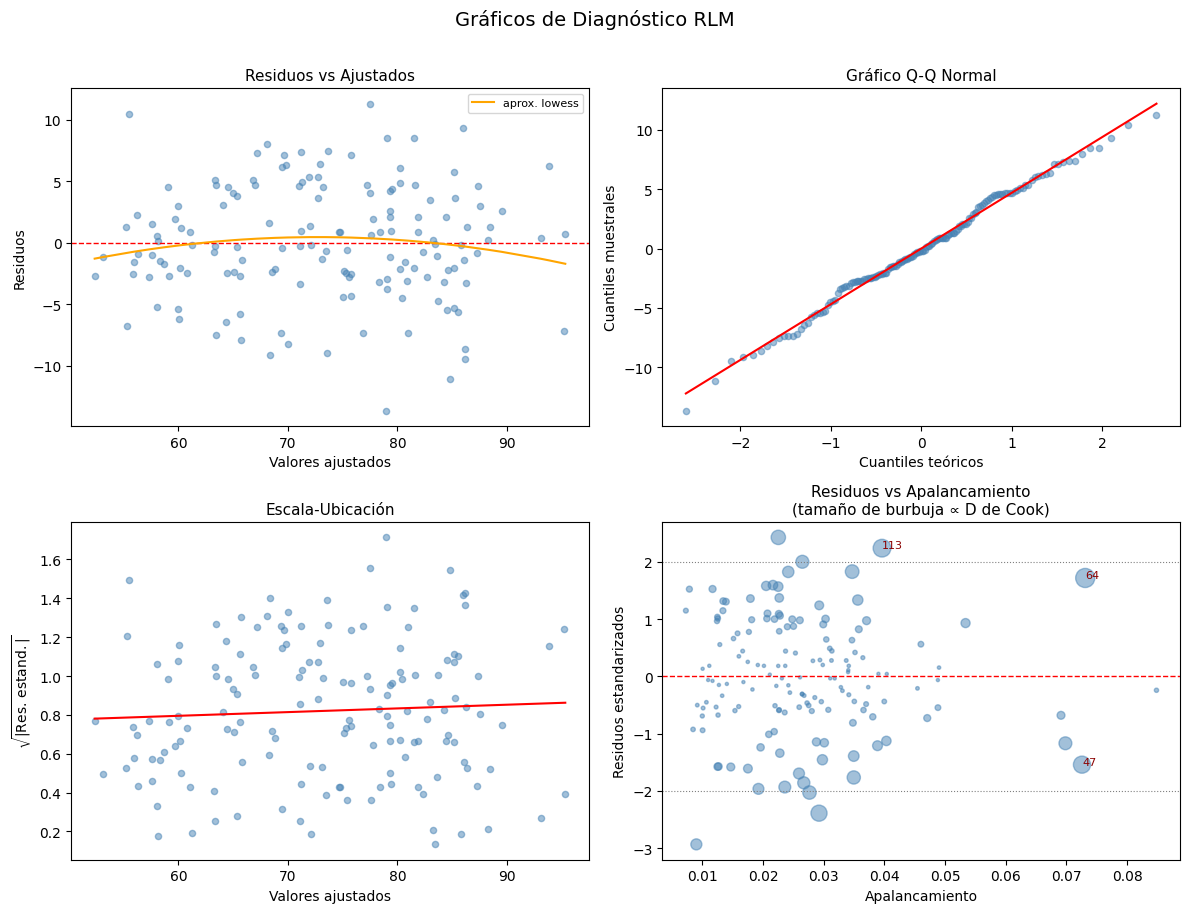


Factores de Inflación de la Varianza
Variable   VIF
   hours 1.038
   grade 1.000
   sleep 1.038


In [3]:
# ── Panel de Diagnóstico 2×2 ──────────────────────────────────────────────────────────

import scipy.stats as stats

fitted   = mlr.fittedvalues
residuals = mlr.resid
std_resid = residuals / residuals.std()
leverage  = mlr.get_influence().hat_matrix_diag
cooks_d   = mlr.get_influence().cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Gráficos de Diagnóstico RLM', fontsize=14, y=1.01)

# 1. Residuos vs Ajustados
ax = axes[0, 0]
ax.scatter(fitted, residuals, alpha=0.5, s=20, color='steelblue')
ax.axhline(0, color='red', linewidth=1, linestyle='--')
# Línea de tendencia suavizada
z = np.polyfit(fitted, residuals, 2)
p = np.poly1d(z)
x_sorted = np.sort(fitted)
ax.plot(x_sorted, p(x_sorted), color='orange', linewidth=1.5, label='aprox. lowess')
ax.set_xlabel('Valores ajustados', fontsize=10)
ax.set_ylabel('Residuos', fontsize=10)
ax.set_title('Residuos vs Ajustados', fontsize=11)
ax.legend(fontsize=8)

# 2. Gráfico QQ Normal
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=20, color='steelblue')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Cuantiles teóricos', fontsize=10)
ax.set_ylabel('Cuantiles muestrales', fontsize=10)
ax.set_title('Gráfico Q-Q Normal', fontsize=11)

# 3. Escala-Ubicación (raíz de |residuos estandarizados| vs ajustados)
ax = axes[1, 0]
sqrt_abs_resid = np.sqrt(np.abs(std_resid))
ax.scatter(fitted, sqrt_abs_resid, alpha=0.5, s=20, color='steelblue')
z2 = np.polyfit(fitted, sqrt_abs_resid, 1)
p2 = np.poly1d(z2)
ax.plot(x_sorted, p2(x_sorted), color='red', linewidth=1.5)
ax.set_xlabel('Valores ajustados', fontsize=10)
ax.set_ylabel(r'$\sqrt{|\mathrm{Res.\,estand.}|}$', fontsize=10)
ax.set_title('Escala-Ubicación', fontsize=11)

# 4. Residuos vs Apalancamiento (D de Cook como tamaño de burbuja)
ax = axes[1, 1]
ax.scatter(leverage, std_resid, s=cooks_d * 3000 + 5,
           alpha=0.5, color='steelblue')
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.axhline(2, color='grey', linewidth=0.8, linestyle=':')
ax.axhline(-2, color='grey', linewidth=0.8, linestyle=':')
# Anotar los puntos más influyentes
top_idx = np.argsort(cooks_d)[-3:]
for idx in top_idx:
    ax.annotate(str(idx), (leverage[idx], std_resid[idx]),
                fontsize=8, color='darkred')
ax.set_xlabel('Apalancamiento', fontsize=10)
ax.set_ylabel('Residuos estandarizados', fontsize=10)
ax.set_title("Residuos vs Apalancamiento\n(tamaño de burbuja \u221d D de Cook)", fontsize=11)

plt.tight_layout()
plt.show()

# VIF
X_vif = df[['hours', 'grade', 'sleep']].copy()
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    'Variable': X_vif.columns[1:],
    'VIF': [variance_inflation_factor(X_vif.values, i+1)
            for i in range(X_vif.shape[1]-1)]
})
print('\nFactores de Inflación de la Varianza')
print(vif_data.round(3).to_string(index=False))

## 4. Métodos de Selección de Variables

### Criterios de Información

| Criterio | Fórmula | Favorece |
|---|---|---|
| AIC | $-2\ell + 2p$ | Precisión predictiva |
| BIC | $-2\ell + p\ln n$ | Parsimonia (penaliza más para $n$ grande) |
| $R^2$ ajustado | $1-(1-R^2)(n-1)/(n-p-1)$ | Explica varianza, ajustado por $p$ |

### Selección por Pasos

| Estrategia | Proceso | Riesgo |
|---|---|---|
| Hacia adelante | Comenzar vacío, agregar predictores uno a uno | Puede omitir combinaciones importantes |
| Hacia atrás | Comenzar completo, eliminar predictores uno a uno | Puede fallar si $p > n$ |
| Por pasos | Alterna hacia adelante y hacia atrás | Inflación de error tipo I por pruebas múltiples |

> **Precaución:** La selección por pasos infla el error tipo I y produce $R^2$ optimistas. Úsela para exploración, no para inferencia.

### Regularización (Contracción)

Tanto Ridge como Lasso resuelven un problema de mínimos cuadrados penalizado:

$$
\hat{\boldsymbol{\beta}}_{\text{Ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|_2^2 \right\}
$$

$$
\hat{\boldsymbol{\beta}}_{\text{Lasso}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}\|_1 \right\}
$$

Ridge tiene forma cerrada: $\hat{\boldsymbol{\beta}}_{\text{Ridge}} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y}$.

**Diferencia clave:** Lasso fija algunos coeficientes exactamente en cero (selección de variables); Ridge contrae todos hacia cero pero nunca exactamente.

Comparación de coeficientes: MCO vs Ridge vs Lasso
(Todos los predictores estandarizados, lambda=1)
Variable  True    OLS  Ridge  Lasso
      x1   3.0  3.099  3.084  3.094
      x2  -2.0 -2.219 -2.208 -2.214
      x3   1.5  1.555  1.549  1.550
      x4  -1.0 -0.874 -0.870 -0.869
      x5   0.0 -0.053 -0.054 -0.048
      x6   0.0 -0.072 -0.071 -0.067
      x7   0.0  0.105  0.102  0.098
      x8   0.0  0.036  0.036  0.030
      x9   0.0  0.062  0.060  0.055
     x10   0.0 -0.076 -0.075 -0.071

R² VC 5 particiones: MCO=0.803, Ridge=0.803, Lasso=0.803


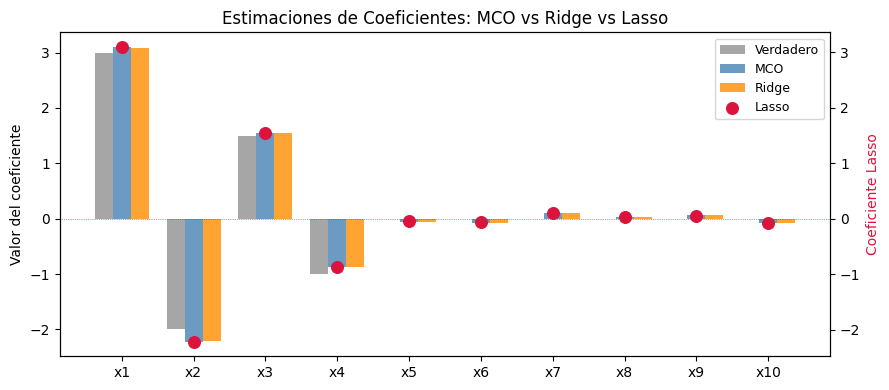

In [4]:
# ── Comparación MCO vs Ridge vs Lasso ─────────────────────────────────────────────────

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

np.random.seed(77)
n2 = 200
p2 = 10  # algunos predictores verdaderos, algunos ruido

X_all = np.random.normal(0, 1, (n2, p2))
# Solo los primeros 4 predictores tienen coeficientes verdaderos no cero
beta_true = np.array([3.0, -2.0, 1.5, -1.0, 0, 0, 0, 0, 0, 0])
y2 = X_all @ beta_true + np.random.normal(0, 2, n2)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

lam = 1.0

ols   = LinearRegression().fit(X_scaled, y2)
ridge = Ridge(alpha=lam).fit(X_scaled, y2)
lasso = Lasso(alpha=lam / n2, max_iter=10000).fit(X_scaled, y2)

coef_df = pd.DataFrame({
    'Variable':   [f'x{j+1}' for j in range(p2)],
    'True':       beta_true,
    'OLS':        ols.coef_,
    'Ridge':      ridge.coef_,
    'Lasso':      lasso.coef_
})
print('Comparación de coeficientes: MCO vs Ridge vs Lasso')
print('(Todos los predictores estandarizados, lambda=1)')
print('='*60)
print(coef_df.round(3).to_string(index=False))

# R^2 con validación cruzada
r2_ols   = cross_val_score(LinearRegression(), X_scaled, y2, cv=5,
                            scoring='r2').mean()
r2_ridge = cross_val_score(Ridge(alpha=lam), X_scaled, y2, cv=5,
                            scoring='r2').mean()
r2_lasso = cross_val_score(Lasso(alpha=lam/n2, max_iter=10000), X_scaled, y2,
                            cv=5, scoring='r2').mean()
print(f'\nR\u00b2 VC 5 particiones: MCO={r2_ols:.3f}, Ridge={r2_ridge:.3f}, Lasso={r2_lasso:.3f}')

# Graficar estimaciones de coeficientes
fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(p2)
width = 0.25
ax.bar(x_pos - width, coef_df['True'],  width, label='Verdadero', color='grey',      alpha=0.7)
ax.bar(x_pos,         coef_df['OLS'],   width, label='MCO',       color='steelblue', alpha=0.8)
ax.bar(x_pos + width, coef_df['Ridge'], width, label='Ridge',     color='darkorange',alpha=0.8)
ax2 = ax.twinx()
ax2.scatter(x_pos, coef_df['Lasso'], color='crimson', s=70, zorder=5, label='Lasso')
ax2.axhline(0, color='crimson', linewidth=0.5, linestyle=':')
ax2.set_ylabel('Coeficiente Lasso', color='crimson', fontsize=10)
ax.set_xticks(x_pos)
ax.set_xticklabels(coef_df['Variable'])
ax.set_ylabel('Valor del coeficiente', fontsize=10)
ax.set_title('Estimaciones de Coeficientes: MCO vs Ridge vs Lasso', fontsize=12)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()